# 3. Data Collection & Time Series

Langkah besarnya:
1. Definisikan batas wilayah (GeoJSON) Desa Bundah.
2. Ambil data NO2 & CO dari Sentinel-5P untuk 1 Sep 2025 – 31 Agu 2026.
3. Simpan ke CSV.
4. Plot time series.


## 0. Siapkan batas wilayah (GeoJSON)

1. Buka https://geojson.io/
2. Cari lokasi Desa Bundah, Kecamatan Sreseh, Kabupaten Sampang
   (titik tengah kira-kira **-7.1781, 113.0548**).
3. Gambar polygon di sekitar area yang mau dianalisis (misalnya area
   pemukiman + pesisir desa).
4. Copy hasilnya (menu di kanan bawah geojson.io)
   `../geojson/bundah_sreseh_sampang.geojson` (file ini sudah diisi kotak
   sementara sebagai contoh, ganti dengan polygon yang lebih akurat).

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open("../geojson/bundah_sreseh_sampang.geojson") as f:
    aoi = json.load(f)

START_DATE = "2025-09-01"
END_DATE   = "2026-08-31"
aoi

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'properties': {'name': 'Montong, Kabupaten Tuban, Jawa Timur'},
   'geometry': {'type': 'Polygon',
    'coordinates': [[[111.80075, -7.033921],
      [111.96733, -7.033921],
      [111.96733, -6.915008],
      [111.80075, -6.915008],
      [111.80075, -7.033921]]]}}]}

## CDSE openEO



In [ ]:
import openeo

connection = openeo.connect("openeofed.dataspace.copernicus.eu")
connection.authenticate_oidc()  # ikuti link login yang muncul di output

In [ ]:
# Cek koleksi tersedia (opsional, untuk memastikan nama koleksi & band masih sama)
# print(connection.list_collection_ids())
# print(connection.describe_collection("SENTINEL_5P_L2"))

cube_no2 = connection.load_collection(
    "SENTINEL_5P_L2",
    spatial_extent=aoi,
    temporal_extent=[START_DATE, END_DATE],
    bands=["NO2"],
)
no2_ts = cube_no2.aggregate_spatial(geometries=aoi, reducer="mean")

cube_co = connection.load_collection(
    "SENTINEL_5P_L2",
    spatial_extent=aoi,
    temporal_extent=[START_DATE, END_DATE],
    bands=["CO"],
)
co_ts = cube_co.aggregate_spatial(geometries=aoi, reducer="mean")

In [ ]:
# Rentang 1 tahun cukup berat untuk dijalankan synchronous -> pakai batch job.
# Batch job openEO memakai "processing units" dari kuota gratis akun CDSE,
# jadi kalau kuota terbatas, pertimbangkan mempersempit polygon atau
# menurunkan frekuensi (mis. tiap 5 hari) di temporal_extent.

no2_job = no2_ts.create_job(title="no2_bundah_sreseh_1thn", out_format="JSON")
no2_job.start_and_wait()
no2_job.get_results().download_file("../data/no2_raw.json")

co_job = co_ts.create_job(title="co_bundah_sreseh_1thn", out_format="JSON")
co_job.start_and_wait()
co_job.get_results().download_file("../data/co_raw.json")

In [ ]:
# Parse hasil openEO (format timeseries JSON: {timestamp: [[value]]}) jadi DataFrame rapi
def load_openeo_timeseries(path, colname):
    with open(path) as f:
        raw = json.load(f)
    rows = []
    for ts, values in raw.items():
        # values biasanya nested list per-band per-polygon, ambil nilai pertama
        v = values[0][0] if values and values[0] else None
        rows.append({"date": ts[:10], colname: v})
    return pd.DataFrame(rows)

df_no2 = load_openeo_timeseries("../data/no2_raw.json", "no2")
df_co  = load_openeo_timeseries("../data/co_raw.json", "co")

df = pd.merge(df_no2, df_co, on="date", how="outer")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df.head()

In [7]:
final_df = pd.read_csv("../data/kualitas_udara_bundah_sreseh.csv", parse_dates=["date"]) 

## Simpan ke CSV

Pakai `df` (dari Opsi A) atau `df_gee` 

In [ ]:
final_df = df  # ganti jadi df_gee kalau pakai Opsi B
final_df.to_csv("../data/kualitas_udara_bundah_sreseh.csv", index=False)
final_df.tail()

## Grafik time series

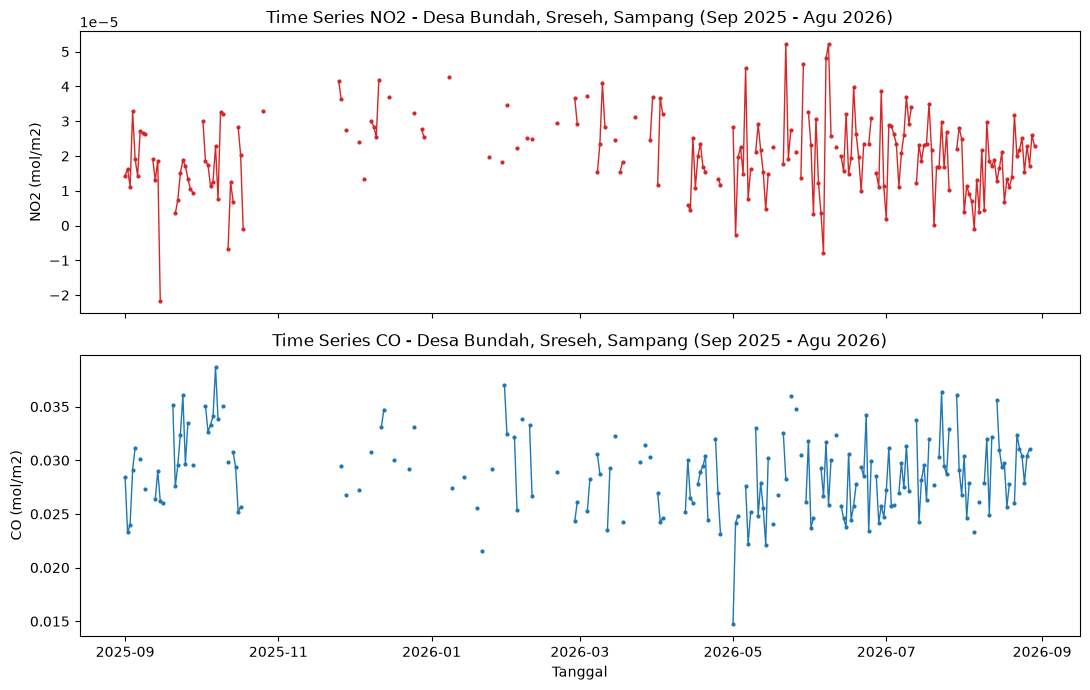

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(final_df["date"], final_df["no2"], color="tab:red", marker="o", markersize=2, linewidth=1)
axes[0].set_title("Time Series NO2 - Desa Bundah, Sreseh, Sampang (Sep 2025 - Agu 2026)")
axes[0].set_ylabel("NO2 (mol/m2)")

axes[1].plot(final_df["date"], final_df["co"], color="tab:blue", marker="o", markersize=2, linewidth=1)
axes[1].set_title("Time Series CO - Desa Bundah, Sreseh, Sampang (Sep 2025 - Agu 2026)")
axes[1].set_ylabel("CO (mol/m2)")
axes[1].set_xlabel("Tanggal")

plt.tight_layout()
plt.savefig("../data/time_series_no2_co.png", dpi=150)
plt.show()

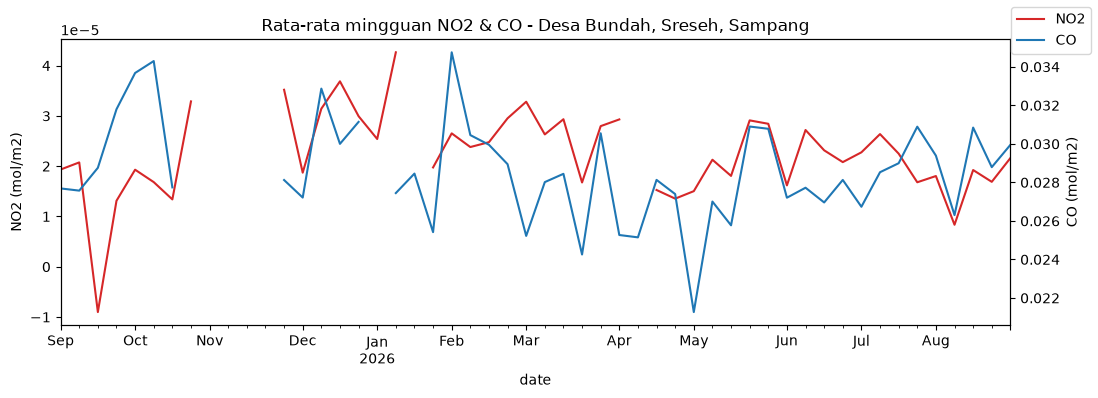

In [9]:
# Versi rata-rata mingguan supaya tren lebih terbaca (mengurangi efek bolong data akibat awan)
weekly = final_df.set_index("date").resample("W").mean()

fig, ax = plt.subplots(figsize=(11, 4))
weekly["no2"].plot(ax=ax, label="NO2", color="tab:red")
ax.set_ylabel("NO2 (mol/m2)")
ax2 = ax.twinx()
weekly["co"].plot(ax=ax2, label="CO", color="tab:blue")
ax2.set_ylabel("CO (mol/m2)")
ax.set_title("Rata-rata mingguan NO2 & CO - Desa Bundah, Sreseh, Sampang")
fig.legend(loc="upper right")
plt.tight_layout()
plt.show()